In [201]:
from datasets import load_from_disk
from rdkit import Chem
import selfies as sf
from data_utils import prepare_rejected_input_mol_string
from rdkit.Chem import Draw
from data_utils import mol2graph, graph2data
import numpy as np
import copy
import re
from tqdm import tqdm

def map_rejected_selfies_to_dataset(data_point):
    input_mol_string = data_point['input_mol_string']

    selfies = input_mol_string.replace("<SELFIES> ", "").replace(" </SELFIES>", "")
    rejected_selfies = augment_molecular_size_based_on_mol(selfies=selfies, preference_type='negative-size')
    rejected_selfies = "<SELFIES> " + rejected_selfies + " </SELFIES>"

    data_point['rejected_input_mol_string'] = rejected_selfies

    return data_point

def map_rejected_mol_to_dataset(data_point):
    input_mol_string = data_point['input_mol_string']

    selfies = input_mol_string.replace("<SELFIES> ", "").replace(" </SELFIES>", "")
    smiles = sf.decoder(selfies)
    mol = Chem.MolFromSmiles(smiles)
    Chem.SanitizeMol(mol)
    rejected_mol = augment_molecular_size_based_on_mol(mol=mol)
    rejected_smiles = Chem.MolToSmiles(rejected_mol['mol']).replace('->', '-').replace('<-', '-')
    rejected_selfies = sf.encoder(rejected_smiles)
    rejected_input_mol_string = "<SELFIES> " + rejected_selfies + " </SELFIES>"

    data_point['rejected_input_mol_string'] = rejected_input_mol_string

    return data_point

def map_with_tqdm(func, iterable):
    from tqdm import tqdm
    list_output = []
    for i in tqdm(iterable):
        list_output.append(func(i))
    return list_output

def augment_molecular_size_based_on_selfies(selfies, min_r=0.3, max_r=0.9):
    smiles = sf.decoder(selfies)
    mol = Chem.MolFromSmiles(smiles)
    num_atoms = mol.GetNumAtoms()
    min_atoms = max(1, int(num_atoms * min_r))
    max_atoms = min(int(num_atoms * max_r), num_atoms - 1)
    try:
        num_changing_atoms = max(np.random.randint(min_atoms, max_atoms), 1)
    except:
        print(smiles)

    prob = np.random.rand()
    if num_atoms == 1:
        edit_mol = add_atoms_based_on_selfies(selfies, num_atoms_to_add=1)
    elif prob > 0.5:
        edit_mol = add_atoms_based_on_selfies(
            selfies, num_atoms_to_add=num_changing_atoms
        )
    else:
        edit_mol = remove_atoms_based_on_selfies(
            selfies, num_atoms_to_remove=num_changing_atoms
        )

    assert edit_mol is not None

    return edit_mol


def augment_molecular_structure_based_on_selfies(selfies):
    return selfies

def add_atoms_based_on_selfies(selfies, num_atoms_to_add):
    edit_selfies = copy.copy(selfies)
    atoms = re.findall("\[.+?\]", selfies)
    while num_atoms_to_add > 0:
        try:
            selected_atom = np.random.choice(atoms).item()
            edit_selfies_parts = list(re.finditer("\[.+?\]", edit_selfies))
            edit_index = np.random.choice(edit_selfies_parts).start()
            new_selfies = (
                edit_selfies[:edit_index] + selected_atom + edit_selfies[edit_index:]
            )

            new_smiles = sf.decoder(new_selfies)
            new_mol = Chem.MolFromSmiles(new_smiles)
            Chem.SanitizeMol(new_mol)

            edit_selfies = new_selfies
            num_atoms_to_add -= 1
        except:
            break

    return edit_selfies


def remove_atoms_based_on_selfies(selfies, num_atoms_to_remove):
    edit_selfies = copy.copy(selfies)
    while num_atoms_to_remove > 0:
        try:
            edit_selfies_parts = list(re.finditer("\[.+?\]", edit_selfies))
            selected_part = np.random.choice(edit_selfies_parts)
            edit_index = selected_part.start()
            edit_len = len(selected_part.group())
            new_selfies = (
                edit_selfies[:edit_index] + edit_selfies[edit_index + edit_len :]
            )

            new_smiles = sf.decoder(edit_selfies)
            new_mol = Chem.MolFromSmiles(new_smiles)
            Chem.SanitizeMol(new_mol)

            edit_selfies = new_selfies
            num_atoms_to_remove -= 1
        except:
            break

    return edit_selfies


from collections import Counter

def get_unique_atoms_and_counts(molecule):
    """
    Get a list of unique atoms and their counts in the given RDKit molecule object.

    Args:
    molecule (rdkit.Chem.Mol): RDKit molecule object.

    Returns:
    dict: A dictionary with atom symbols as keys and their counts as values.
    """
    # Extract atom symbols from the molecule
    atom_symbols = [atom.GetSymbol() for atom in molecule.GetAtoms()]

    # Count occurrences of each atom symbol
    atom_counts = Counter(atom_symbols)

    return dict(atom_counts)


def sample_atom(atom_counts):
    """
    Sample an atom from the atom_counts with a probability proportional to its count.

    Args:
    atom_counts (dict): Dictionary of atom symbols and their counts.

    Returns:
    str: A sampled atom symbol based on its relative abundance.
    """
    # Extract atoms and their respective counts
    atoms = list(atom_counts.keys())
    counts = list(atom_counts.values())

    # Sample one atom based on the counts as weights
    sampled_atom = np.random.choice(atoms, p=np.array(counts) / np.sum(counts)).item()

    return sampled_atom

def augment_molecular_size_based_on_mol(mol, min_r=0.3, max_r=0.9):
    num_atoms = mol.GetNumAtoms()
    min_atoms = max(1, int(num_atoms * min_r))
    max_atoms = min(int(num_atoms * max_r), num_atoms - 1)

    if min_atoms >= max_atoms:
        edit_mol = add_atoms_based_on_mol(mol, num_atoms_to_add=min_atoms)
    else:
        num_changing_atoms = np.random.randint(min_atoms, max_atoms)

        prob = np.random.rand()

        if prob > 0.5:
            edit_mol = add_atoms_based_on_mol(
                mol, num_atoms_to_add=num_changing_atoms
            )
        else:
            edit_mol = remove_atoms_based_on_mol(
                mol, num_atoms_to_remove=num_changing_atoms
            )

    assert edit_mol is not None

    return edit_mol


def remove_atoms_based_on_mol(mol, num_atoms_to_remove):
    assert (
        num_atoms_to_remove < mol.GetNumAtoms()
    ), "num_atoms_to_remove should be less than the number of atoms in the molecule."
    assert num_atoms_to_remove > 0, "num_atoms_to_remove should be positive."

    sanitized_mol = Chem.RWMol(mol)

    while num_atoms_to_remove > 0:
        potential_remove_indices = []
        for atom in sanitized_mol.GetAtoms():
            # Check if all neighbors are connected by single bonds
            # to guarantee that the new bond will be single, so that might be kekulizable...
            all_single_bonds = True
            for neighbor in atom.GetNeighbors():
                bond = sanitized_mol.GetBondBetweenAtoms(
                    atom.GetIdx(), neighbor.GetIdx()
                )
                if bond.GetBondType() != Chem.rdchem.BondType.SINGLE:
                    all_single_bonds = False
                    break
            if all_single_bonds:
                potential_remove_indices.append(atom.GetIdx())

        if not potential_remove_indices:
            break

        np.random.shuffle(potential_remove_indices)

        change_made = False
        for atom_index in potential_remove_indices:
            try:
                rw_mol = Chem.RWMol(sanitized_mol)
                rw_mol.RemoveAtom(atom_index)
                Chem.SanitizeMol(rw_mol)
                sanitized_mol = rw_mol.GetMol()
                num_atoms_to_remove -= 1
                change_made = True
                break
            except:
                continue

        if not change_made:
            break

    out = {
        "mol": sanitized_mol,
        "original_num_atoms": mol.GetNumAtoms(),
        "augmeted_num_atoms": sanitized_mol.GetNumAtoms(),
        "num_not_fulfilled_changes": num_atoms_to_remove,
    }
    return out


def add_atoms_based_on_mol(mol, num_atoms_to_add):
    assert num_atoms_to_add > 0, "num_atoms_to_add should be positive."

    sanitized_mol = Chem.RWMol(mol)
    atom_counts = get_unique_atoms_and_counts(sanitized_mol)

    while num_atoms_to_add > 0:
        potential_attaching_indices = []
        for atom in sanitized_mol.GetAtoms():
            all_single_bonds = all([bond.GetBondType() == Chem.rdchem.BondType.SINGLE for bond in atom.GetBonds()])

            if atom.GetImplicitValence() > 0 or not all_single_bonds:
                potential_attaching_indices.append(atom.GetIdx())

        if not potential_attaching_indices:
            break

        np.random.shuffle(potential_attaching_indices)

        change_made = False
        for atom_index in potential_attaching_indices:
            try:
                rw_mol = Chem.RWMol(sanitized_mol)
                new_atom = Chem.Atom(sample_atom(atom_counts))
                new_atom_idx = rw_mol.AddAtom(new_atom)
                attaching_atom = rw_mol.GetAtomWithIdx(atom_index)
                if attaching_atom.GetTotalValence() <= attaching_atom.GetExplicitValence():
                    # remove one bond other than single bond
                    bonds = attaching_atom.GetBonds()
                    one_level_downgrade = {
                        Chem.rdchem.BondType.DOUBLE: Chem.rdchem.BondType.SINGLE,
                        Chem.rdchem.BondType.TRIPLE: Chem.rdchem.BondType.DOUBLE,
                    }
                    bonds = [bond for bond in bonds if bond.GetBondType() in one_level_downgrade]
                    np.random.shuffle(bonds)
                    bond = bonds[0]
                    new_bond_type = one_level_downgrade[bond.GetBondType()]
                    rw_mol.RemoveBond(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx())
                    rw_mol.AddBond((bond.GetBeginAtomIdx(), bond.GetEndAtomIdx(), new_bond_type))

                rw_mol.AddBond(
                    atom_index, new_atom_idx, order=Chem.rdchem.BondType.SINGLE
                )
                
                Chem.SanitizeMol(rw_mol)
                sanitized_mol = rw_mol.GetMol()
                atom_counts[new_atom.GetSymbol()] += 1
                num_atoms_to_add -= 1
                change_made = True
                break
            except:
                continue

        if not change_made:
            break

    out = {
        "mol": sanitized_mol,
        "original_num_atoms": mol.GetNumAtoms(),
        "augmeted_num_atoms": sanitized_mol.GetNumAtoms(),
        "num_not_fulfilled_changes": num_atoms_to_add,
    }
    return out

In [4]:
dataset_paths = [
    '/data/data/Mol-LLM-v7.1/mistralai-Mistral-7B-Instruct-v0.3_string+graph_q32_test_property_prediction_small',
    '/data/data/Mol-LLM-v7.1/mistralai-Mistral-7B-Instruct-v0.3_string+graph_q32_validation_property_prediction_small',
    '/data/data/Mol-LLM-v7.1/mistralai-Mistral-7B-Instruct-v0.3_string+graph_q32_train_property_prediction_small',
]

In [206]:
for p in dataset_paths:
    dataset = load_from_disk(p)
    dataset = dataset.map(map_rejected_mol_to_dataset,
                            batched=False,
                            num_proc=36,
                            )
    dataset.save_to_disk(p + '_offline')
    print('Done with', p)

Saving the dataset (1/1 shards): 100%|██████████| 7142/7142 [00:00<00:00, 9826.96 examples/s]


Done with /data/data/Mol-LLM-v7.1/mistralai-Mistral-7B-Instruct-v0.3_string+graph_q32_test_property_prediction_small


Map (num_proc=36):   0%|          | 1/7142 [00:01<3:41:18,  1.86s/ examples][08:01:37] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6
[08:01:37] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4
Map (num_proc=36):   0%|          | 31/7142 [00:02<05:12, 22.73 examples/s] [08:01:38] Can't kekulize mol.  Unkekulized atoms: 1 2 17 18 19 20 21 22 23
[08:01:38] Can't kekulize mol.  Unkekulized atoms: 0 1 16 17 18 19 20 21 22
Map (num_proc=36):   1%|          | 60/7142 [00:02<02:18, 51.16 examples/s][08:01:38] Can't kekulize mol.  Unkekulized atoms: 5 13 14 15 16 17 18
[08:01:38] Can't kekulize mol.  Unkekulized atoms: 4 12 13 14 15 16 17
[08:01:38] Can't kekulize mol.  Unkekulized atoms: 19 20 21 22 23 24 25
[08:01:38] Can't kekulize mol.  Unkekulized atoms: 4 12 13 14 15 16 17
[08:01:38] Can't kekulize mol.  Unkekulized atoms: 2 17 18 19 20 21 22
[08:01:38] Can't kekulize mol.  Unkekulized atoms: 8 11 12 13 14 15 16
[08:01:38] Can't kekulize mol.  Unkekulized atoms: 4 9 10 11 12 13 14
[0

Done with /data/data/Mol-LLM-v7.1/mistralai-Mistral-7B-Instruct-v0.3_string+graph_q32_validation_property_prediction_small


Map (num_proc=36):   0%|          | 0/394063 [00:00<?, ? examples/s][08:02:24] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7
[08:02:24] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6
Map (num_proc=36):   0%|          | 10/394063 [00:00<6:51:20, 15.97 examples/s][08:02:24] Can't kekulize mol.  Unkekulized atoms: 2 3 4
[08:02:24] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 5
Map (num_proc=36):   0%|          | 82/394063 [00:00<44:57, 146.07 examples/s] [08:02:24] Can't kekulize mol.  Unkekulized atoms: 2 3 4
[08:02:24] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4
[08:02:24] Can't kekulize mol.  Unkekulized atoms: 2 3 4
[08:02:24] Can't kekulize mol.  Unkekulized atoms: 2 3 4
Map (num_proc=36):   0%|          | 197/394063 [00:00<18:53, 347.45 examples/s][08:02:24] Can't kekulize mol.  Unkekulized atoms: 2 3 4
[08:02:24] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4
[08:02:24] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4
[08:02:24] Can't kekulize mol.  Unkekulized 

Done with /data/data/Mol-LLM-v7.1/mistralai-Mistral-7B-Instruct-v0.3_string+graph_q32_train_property_prediction_small


In [208]:
datasets = [load_from_disk(p + '_offline') for p in dataset_paths]

In [209]:
_list_input_mol_string = datasets[-1]['input_mol_string']
_list_selfies = map_with_tqdm(lambda x: x.replace("<SELFIES> ", "").replace(" </SELFIES>", ""), _list_input_mol_string)
_list_smiles = map_with_tqdm(sf.decoder, _list_selfies)
_list_mols = map_with_tqdm(Chem.MolFromSmiles, _list_smiles)

  7%|▋         | 26877/394063 [00:01<00:24, 15009.91it/s][08:10:58] WARNING: not removing hydrogen atom without neighbors
[08:10:58] WARNING: not removing hydrogen atom without neighbors
 16%|█▌        | 63789/394063 [00:04<00:21, 15399.66it/s][08:11:00] WARNING: not removing hydrogen atom without neighbors
[08:11:00] WARNING: not removing hydrogen atom without neighbors
[08:11:00] WARNING: not removing hydrogen atom without neighbors
 97%|█████████▋| 380716/394063 [00:25<00:00, 14835.71it/s][08:11:21] WARNING: not removing hydrogen atom without neighbors
[08:11:21] WARNING: not removing hydrogen atom without neighbors
100%|██████████| 394063/394063 [00:26<00:00, 15153.17it/s]


In [212]:
len(datasets[-1]['rejected_input_mol_string'])

394063

In [213]:
_list_rejected_input_mol_string = datasets[-1]['rejected_input_mol_string']
_list_rejected_selfies = map_with_tqdm(lambda x: x.replace("<SELFIES> ", "").replace(" </SELFIES>", ""), _list_rejected_input_mol_string)
_list_rejected_smiles = map_with_tqdm(sf.decoder, _list_rejected_selfies)
_list_rejected_mols = map_with_tqdm(Chem.MolFromSmiles, _list_rejected_smiles)

  7%|▋         | 26625/394063 [00:01<00:22, 16229.62it/s][08:18:43] WARNING: not removing hydrogen atom without neighbors
[08:18:43] WARNING: not removing hydrogen atom without neighbors
 16%|█▌        | 63045/394063 [00:03<00:20, 16185.28it/s][08:18:45] WARNING: not removing hydrogen atom without neighbors
[08:18:45] WARNING: not removing hydrogen atom without neighbors
[08:18:45] WARNING: not removing hydrogen atom without neighbors
 97%|█████████▋| 381010/394063 [00:23<00:00, 16029.81it/s][08:19:05] WARNING: not removing hydrogen atom without neighbors
[08:19:05] WARNING: not removing hydrogen atom without neighbors
100%|██████████| 394063/394063 [00:24<00:00, 16184.48it/s]


In [214]:
invalid_rejected_idxs = []
iter_bar = tqdm(range(len(_list_rejected_mols)))
for i in iter_bar:
    try:
        mol2graph(_list_rejected_mols[i])
    except:
        invalid_rejected_idxs.append(i)
invalid_rejected_idxs

100%|██████████| 394063/394063 [02:35<00:00, 2541.68it/s]


[]

In [204]:
list_invalid_rejected_mols = [_list_rejected_mols[i] for i in invalid_rejected_idxs]
list_invalid_rejected_selfies = [_list_rejected_selfies[i] for i in invalid_rejected_idxs]
list_invalid_mols = [_list_mols[i] for i in invalid_rejected_idxs]
list_invalid_selfies = [_list_selfies[i] for i in invalid_rejected_idxs]

In [207]:
list_invalid_selfies

[]

In [72]:
rejected_selfies = augment_molecular_size_based_on_selfies(list_invalid_selfies[0])
rejected_selfies

[04:57:10] Explicit valence for atom # 3 Sn, 5, is greater than permitted


'[=C][C][=C][Ring1][Sn][Branch1][Ring1][=C][Ring1][C][=C][Branch1][S][O][C][=C][C][=C][C][=C][C][=C][=C][N][=C][Ring1][=Branch1][#Branch2][Ring1][=Branch1][O][C][=C][=C][C][=C][C][=C][C][=C][N][Ring1][=C][=C][Ring1][C][=C][#Branch2][Ring1][=Branch1]'

In [71]:
rejected_smiles

'C=1=C[Sn]=1(SOC=CC=CC=CC=CN=C)OC2=CC=CC3=CC=CN=C23'

In [202]:
rejected_smiles = sf.decoder(rejected_selfies)
rejected_mol = Chem.MolFromSmiles(rejected_smiles)
rejected_mol.GetNumAtoms()

3

In [23]:
list_rejected_smiles = [
    'CCC=O', 'CCC[Sn](CCC)(OC(=O)C1C=CC=C(C)C1[Sn])(CCC)(CCC)OC(=O)CC2=CC=C(F)C=C2', 
    'COCC(CC)=CC1=CC1', 'N1CC1(C2)CC2', 'CNC=CO'
    ]
list_rejected_mol = [
    Chem.MolFromSmiles(smiles) for smiles in list_rejected_smiles
    ]

[03:21:59] Explicit valence for atom # 3 Sn, 6, is greater than permitted


[06:58:08] Explicit valence for atom # 3 Sn, 6, is greater than permitted


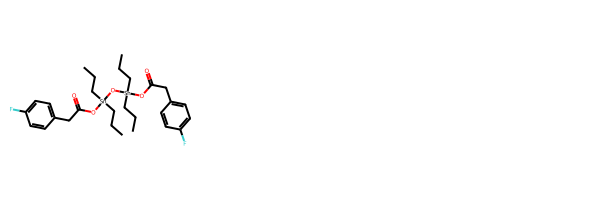

In [179]:
origin_selfies = '[C][C][C][Sn][Branch1][Ring2][C][C][C][Branch2][Ring1][C][O][C][=Branch1][C][=O][C][C][=C][C][=C][Branch1][C][F][C][=C][Ring1][#Branch1][O][Sn][Branch1][Ring2][C][C][C][Branch1][Ring2][C][C][C][O][C][=Branch1][C][=O][C][C][=C][C][=C][Branch1][C][F][C][=C][Ring1][#Branch1]'
origin_smiles = sf.decoder(origin_selfies)
origin_mol = Chem.MolFromSmiles(origin_smiles)
Chem.SanitizeMol(origin_mol)
problematic_selfies = '[C][C][C][Sn][Branch1][Ring2][C][C][C][Branch2][Ring1][C][O][C][=Branch1][C][=O][C][C][=C][C][=C][Branch1][C][C][=C][Ring1][#Branch1][Sn][Branch1][Ring2][C][C][C][Branch1][Ring2][C][C][C][O][C][=Branch1][C][=O][C][C][=C][C][=C][Branch1][C][F][C][=C][Ring1][#Branch1]'
problematic_smiles = sf.decoder(problematic_selfies)    
problematic_mol = Chem.MolFromSmiles(problematic_smiles)

Draw.MolsToGridImage([origin_mol, problematic_mol])

mol <rdkit.Chem.rdchem.Mol object at 0x7f7d0d609540>
original_num_atoms 37
augmeted_num_atoms 50
num_not_fulfilled_changes 0


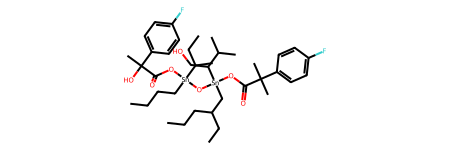

In [183]:
out = augment_molecular_size_based_on_mol(origin_mol)
for k in out:
    print(k, out[k])
out['mol']

In [4]:
for p in dataset_paths:
    dataset = load_from_disk(p)
    dataset = dataset.map(map_rejected_mol_to_dataset,
                            batched=False,
                            num_proc=36,
                            )
    dataset.save_to_disk(p + '_offline')
    print('Done with', p)

Map (num_proc=36):   0%|          | 0/7142 [00:00<?, ? examples/s][07:50:45] WARNING: not removing hydrogen atom without neighbors
[07:50:45] WARNING: not removing hydrogen atom without neighbors
[07:50:45] WARNING: not removing hydrogen atom without neighbors
Map (num_proc=36):   0%|          | 5/7142 [00:00<02:42, 43.86 examples/s][07:50:45] WARNING: not removing hydrogen atom without neighbors
[07:50:45] WARNING: not removing hydrogen atom without neighbors
[07:50:45] WARNING: not removing hydrogen atom without neighbors
[07:50:45] WARNING: not removing hydrogen atom without neighbors
[07:50:45] WARNING: not removing hydrogen atom without neighbors
[07:50:45] WARNING: not removing hydrogen atom without neighbors
[07:50:45] WARNING: not removing hydrogen atom without neighbors
[07:50:45] WARNING: not removing hydrogen atom without neighbors
[07:50:45] WARNING: not removing hydrogen atom without neighbors
[07:50:45] WARNING: not removing hydrogen atom without neighbors
[07:50:45] WARN

Done with /data/data/Mol-LLM-v7.1/mistralai-Mistral-7B-Instruct-v0.3_string+graph_q32_test_property_prediction_small



Map (num_proc=36):  19%|█▉        | 1385/7142 [00:00<00:01, 2948.51 examples/s][07:50:49] Explicit valence for atom # 1 Pb, 6, is greater than permitted
[07:50:49] Explicit valence for atom # 3 Cl, 5, is greater than permitted
[07:50:50] Explicit valence for atom # 1 Cl, 5, is greater than permitted
Map (num_proc=36):  24%|██▍       | 1731/7142 [00:00<00:01, 3113.25 examples/s][07:50:50] WARNING: not removing hydrogen atom without neighbors
[07:50:50] WARNING: not removing hydrogen atom without neighbors
[07:50:50] WARNING: not removing hydrogen atom without neighbors
[07:50:50] WARNING: not removing hydrogen atom without neighbors
[07:50:50] WARNING: not removing hydrogen atom without neighbors
[07:50:50] Explicit valence for atom # 12 Cl, 3, is greater than permitted
[07:50:50] Explicit valence for atom # 8 Sn, 5, is greater than permitted
[07:50:50] Explicit valence for atom # 1 Sn, 5, is greater than permitted
[07:50:50] Explicit valence for atom # 0 I, 6, is greater than permitte

Done with /data/data/Mol-LLM-v7.1/mistralai-Mistral-7B-Instruct-v0.3_string+graph_q32_validation_property_prediction_small



Map (num_proc=36):   2%|▏         | 6472/394063 [00:00<00:34, 11375.15 examples/s][07:50:54] Explicit valence for atom # 7 Sn, 5, is greater than permitted
[07:50:54] Explicit valence for atom # 5 Cl, 3, is greater than permitted
[07:50:54] WARNING: not removing hydrogen atom without neighbors
[07:50:54] WARNING: not removing hydrogen atom without neighbors
[07:50:54] WARNING: not removing hydrogen atom without neighbors
[07:50:54] WARNING: not removing hydrogen atom without neighbors
Map (num_proc=36):  11%|█         | 43513/394063 [00:03<00:27, 12709.76 examples/s][07:50:57] WARNING: not removing hydrogen atom without neighbors
[07:50:57] WARNING: not removing hydrogen atom without neighbors
[07:50:57] WARNING: not removing hydrogen atom without neighbors
[07:50:57] WARNING: not removing hydrogen atom without neighbors
[07:50:57] WARNING: not removing hydrogen atom without neighbors
[07:50:57] WARNING: not removing hydrogen atom without neighbors
[07:50:57] WARNING: not removing hyd

...

[SeH2]


Map (num_proc=36):  69%|██████▉   | 271453/394063 [00:22<00:10, 11545.99 examples/s][07:51:16] WARNING: not removing hydrogen atom without neighbors
[07:51:16] WARNING: not removing hydrogen atom without neighbors
[07:51:16] WARNING: not removing hydrogen atom without neighbors
[07:51:16] WARNING: not removing hydrogen atom without neighbors
[07:51:16] Explicit valence for atom # 2 Sn, 5, is greater than permitted
Map (num_proc=36):  70%|███████   | 277810/394063 [00:22<00:09, 12388.21 examples/s][07:51:16] Explicit valence for atom # 13 Br, 3, is greater than permitted
[07:51:16] Explicit valence for atom # 25 Sn, 5, is greater than permitted
Map (num_proc=36):  71%|███████▏  | 281651/394063 [00:23<00:09, 12475.72 examples/s][07:51:16] Explicit valence for atom # 3 Sn, 6, is greater than permitted
[07:51:16] Explicit valence for atom # 8 Br, 2, is greater than permitted
Map (num_proc=36):  74%|███████▍  | 292209/394063 [00:23<00:07, 12984.67 examples/s][07:51:17] Explicit valence for 

O


Map (num_proc=36):  97%|█████████▋| 383267/394063 [00:31<00:00, 11364.00 examples/s][07:51:25] Explicit valence for atom # 2 Sn, 5, is greater than permitted
[07:51:25] Explicit valence for atom # 0 Cl, 2, is greater than permitted
[07:51:25] Explicit valence for atom # 5 Sn, 6, is greater than permitted
Saving the dataset (3/3 shards): 100%|██████████| 394063/394063 [00:17<00:00, 22602.47 examples/s]

Done with /data/data/Mol-LLM-v7.1/mistralai-Mistral-7B-Instruct-v0.3_string+graph_q32_train_property_prediction_small
